# 05. Integración de fuentes inmobiliarias

## Objetivo

Este notebook integra dos fuentes con funciones diferentes:

1. **Kaggle–Idealista**: anuncios individuales ya limpiados y agregados por barrio. Aporta las características típicas de la oferta residencial: superficie, habitaciones, ascensor, exterior, cobertura y un precio histórico de oferta.
2. **Ayuntamiento de Madrid / Colegio de Registradores (2025)**: precio medio declarado en compraventas por barrio. Aporta una referencia reciente, oficial y con fecha conocida.

La integración se realiza cuando ambas fuentes tienen **una fila por barrio**, utilizando `zone_key` como clave territorial.

> **Decisión metodológica:** no se concatenan los registros de ambas fuentes y no se calcula una media entre sus precios. El precio de Kaggle es una mediana de oferta de fecha desconocida; el dato registral es una media declarada de transacciones de 2025. Se conservan como indicadores distintos.

## Salidas

- `data/processed/registered_housing_price_2025.csv`
- `data/processed/neighborhood_real_estate_enriched.csv`
- `data/processed/neighborhood_real_estate_integration_audit.csv`

In [1]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## 1. Localización del proyecto y definición de rutas

El bloque siguiente encuentra automáticamente la raíz del proyecto tanto si el notebook se ejecuta desde `notebooks/` como desde la carpeta principal.

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Busca la carpeta raíz que contiene simultáneamente data/ y notebooks/."""
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate

    raise FileNotFoundError(
        "No se encontró la raíz del proyecto. Abre el notebook desde "
        "TFG_Recomendador_Viviendas o desde su carpeta notebooks/."
    )


PROJECT_ROOT = find_project_root()

RAW_OFFICIAL_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "official"
    / "housing"
    / "registered_housing_price_2025_raw.csv"
)

ZONES_PATH = PROJECT_ROOT / "data" / "processed" / "zones_master.csv"
KAGGLE_SUMMARY_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "neighborhood_real_estate_summary.csv"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

OFFICIAL_CLEAN_PATH = PROCESSED_DIR / "registered_housing_price_2025.csv"
ENRICHED_PATH = PROCESSED_DIR / "neighborhood_real_estate_enriched.csv"
AUDIT_PATH = PROCESSED_DIR / "neighborhood_real_estate_integration_audit.csv"

required_paths = [RAW_OFFICIAL_PATH, ZONES_PATH, KAGGLE_SUMMARY_PATH]
missing_paths = [path for path in required_paths if not path.exists()]

if missing_paths:
    formatted = "\n".join(f"- {path}" for path in missing_paths)
    raise FileNotFoundError(f"Faltan archivos necesarios:\n{formatted}")

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Fuente oficial: {RAW_OFFICIAL_PATH.relative_to(PROJECT_ROOT)}")
print(f"Resumen de Kaggle: {KAGGLE_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")

Raíz del proyecto: /mnt/data/notebook_test/TFG_Recomendador_Viviendas
Fuente oficial: data/raw/official/housing/registered_housing_price_2025_raw.csv
Resumen de Kaggle: data/processed/neighborhood_real_estate_summary.csv


## 2. Inspección de la fuente oficial

El CSV del Ayuntamiento no tiene una cabecera convencional. Incluye:

- Cinco líneas descriptivas.
- Tres niveles de cabecera.
- Filas de ciudad, distrito y barrio.
- Notas de fuente y observaciones al final.

Antes de leer la tabla se conservan esos metadatos para documentar su procedencia.

In [3]:
raw_lines = RAW_OFFICIAL_PATH.read_text(encoding="utf-8-sig").splitlines()

source_metadata = {
    "subject_area": raw_lines[0],
    "market_section": raw_lines[1],
    "operation_type": raw_lines[2],
    "dataset_title": raw_lines[3],
    "series_title": raw_lines[4],
    "source_note": next(
        (line for line in raw_lines if line.startswith("Fuente:")),
        None,
    ),
    "observations": next(
        (line for line in raw_lines if line.startswith("Observaciones:")),
        None,
    ),
}

for key, value in source_metadata.items():
    print(f"{key}: {value}")

subject_area: E. Edificación y Vivienda
market_section: Mercado de la vivienda
operation_type: Compra-Venta de Viviendas
dataset_title: Estadística registral inmobiliaria: datos anuales por distritos
series_title: 4.2.1.6. Precio medio  declarado de la vivienda (euros/m2) por Distrito y Barrio según Tipo de vivienda
source_note: Fuente: Colegio de Registradores de España
observations: None


## 3. Lectura estructurada

Las once columnas de datos representan:

- Dos campos territoriales.
- Tres precios medios declarados en euros por metro cuadrado: total, vivienda nueva y vivienda usada.
- Tres índices respecto al conjunto de Madrid.
- Tres índices respecto al total de cada territorio.

In [4]:
RAW_COLUMNS = [
    "district_raw",
    "territory_raw",
    "registered_price_m2_total_2025",
    "registered_price_m2_new_2025",
    "registered_price_m2_used_2025",
    "registered_index_madrid_total_2025",
    "registered_index_madrid_new_2025",
    "registered_index_madrid_used_2025",
    "registered_index_type_total_2025",
    "registered_index_type_new_2025",
    "registered_index_type_used_2025",
]

official_raw = pd.read_csv(
    RAW_OFFICIAL_PATH,
    sep=";",
    skiprows=8,
    names=RAW_COLUMNS,
    dtype="string",
    encoding="utf-8-sig",
    engine="python",
)

print(f"Filas leídas, incluidas notas finales: {len(official_raw):,}")
display(official_raw.head())

Filas leídas, incluidas notas finales: 157


,district_raw,territory_raw,registered_price_m2_total_2025,registered_price_m2_new_2025,registered_price_m2_used_2025,registered_index_madrid_total_2025,registered_index_madrid_new_2025,registered_index_madrid_used_2025,registered_index_type_total_2025,registered_index_type_new_2025,registered_index_type_used_2025
0,Ciudad de Madrid,Ciudad de Madrid,"5.285,72","5.041,46","5.333,59",100,100,100,100,"95,38","100,91"
1,01. Centro,01. Centro,"7.147,7","6.814,13","7.171,36","135,23","135,16","134,46",100,"95,33","100,33"
2,01. Centro,011. Palacio,"6.895,15","6.421,28","6.954,58","130,45","127,37","130,39",100,"93,13","100,86"
3,01. Centro,012. Embajadores,"6.054,75","6.153,41","6.044,57","114,55","122,06","113,33",100,"101,63","99,83"
4,01. Centro,013. Cortes,"7.246,75",0,"7.246,75","137,1",0,"135,87",100,0,100


## 4. Selección de barrios y normalización territorial

La segunda columna permite distinguir los niveles geográficos:

- Distrito: código de dos cifras, por ejemplo `01. Centro`.
- Barrio: código de tres cifras, por ejemplo `011. Palacio`.

Solo se conservan las filas de barrio. El código oficial de tres cifras se transforma en `zone_key`, por ejemplo `011 → MAD-011`.

In [5]:
neighborhood_mask = official_raw["territory_raw"].fillna("").str.match(
    r"^\d{3}\.\s"
)

official_neighborhoods = official_raw.loc[neighborhood_mask].copy()

official_neighborhoods[["neighborhood_code_source", "neighborhood_name_source"]] = (
    official_neighborhoods["territory_raw"]
    .str.extract(r"^(\d{3})\.\s*(.+)$")
)

official_neighborhoods[["district_code_source", "district_name_source"]] = (
    official_neighborhoods["district_raw"]
    .str.extract(r"^(\d{2})\.\s*(.+)$")
)

official_neighborhoods["zone_key"] = (
    "MAD-" + official_neighborhoods["neighborhood_code_source"]
)

print(f"Barrios identificados: {len(official_neighborhoods)}")
display(
    official_neighborhoods[
        [
            "zone_key",
            "district_name_source",
            "neighborhood_name_source",
        ]
    ].head()
)

Barrios identificados: 131


,zone_key,district_name_source,neighborhood_name_source
2,MAD-011,Centro,Palacio
3,MAD-012,Centro,Embajadores
4,MAD-013,Centro,Cortes
5,MAD-014,Centro,Justicia
6,MAD-015,Centro,Universidad


## 5. Limpieza numérica

Los números utilizan formato español:

- Punto como separador de miles.
- Coma como separador decimal.

La observación metodológica de la fuente indica que solo se publica el dato de barrio cuando existen al menos **15 casos**. Los ceros no representan un precio real de `0 €/m²`; indican que no existe un valor publicable. Por ello se convierten en valores ausentes.

In [6]:
METRIC_COLUMNS = RAW_COLUMNS[2:]


def parse_spanish_number(series: pd.Series) -> pd.Series:
    """Convierte texto numérico español a float, preservando ausencias."""
    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    return pd.to_numeric(cleaned, errors="coerce")


for column in METRIC_COLUMNS:
    official_neighborhoods[column] = parse_spanish_number(
        official_neighborhoods[column]
    )
    official_neighborhoods[column] = official_neighborhoods[column].replace(
        0,
        np.nan,
    )

official_neighborhoods["registered_price_available"] = (
    official_neighborhoods["registered_price_m2_total_2025"].notna()
)
official_neighborhoods["registered_new_price_available"] = (
    official_neighborhoods["registered_price_m2_new_2025"].notna()
)
official_neighborhoods["registered_used_price_available"] = (
    official_neighborhoods["registered_price_m2_used_2025"].notna()
)

coverage_summary = pd.DataFrame(
    {
        "variable": [
            "Precio total",
            "Vivienda nueva",
            "Vivienda usada",
        ],
        "barrios_con_dato": [
            official_neighborhoods[
                "registered_price_m2_total_2025"
            ].notna().sum(),
            official_neighborhoods[
                "registered_price_m2_new_2025"
            ].notna().sum(),
            official_neighborhoods[
                "registered_price_m2_used_2025"
            ].notna().sum(),
        ],
    }
)
coverage_summary["barrios_sin_dato"] = (
    len(official_neighborhoods) - coverage_summary["barrios_con_dato"]
)
coverage_summary["cobertura_porcentaje"] = (
    coverage_summary["barrios_con_dato"]
    / len(official_neighborhoods)
    * 100
).round(2)

display(coverage_summary)

,variable,barrios_con_dato,barrios_sin_dato,cobertura_porcentaje
0,Precio total,130,1,99.24
1,Vivienda nueva,69,62,52.67
2,Vivienda usada,129,2,98.47


## 6. Validaciones internas de la fuente oficial

Se comprueba que:

- Existen exactamente 131 barrios.
- `zone_key` es único.
- No quedan precios iguales a cero.
- Se identifica explícitamente cualquier barrio sin precio total.

In [7]:
assert len(official_neighborhoods) == 131, (
    "La fuente oficial no contiene exactamente 131 barrios."
)
assert official_neighborhoods["zone_key"].is_unique, (
    "Hay códigos de barrio duplicados en la fuente oficial."
)
assert not (
    official_neighborhoods[METRIC_COLUMNS].fillna(np.nan) == 0
).any().any(), "Quedan ceros que deberían haberse convertido en NaN."

missing_registered_price = official_neighborhoods.loc[
    ~official_neighborhoods["registered_price_available"],
    [
        "zone_key",
        "district_name_source",
        "neighborhood_name_source",
    ],
]

print("Validaciones internas superadas.")
print("Barrios sin precio registrado total:")
display(missing_registered_price)

Validaciones internas superadas.
Barrios sin precio registrado total:


,zone_key,district_name_source,neighborhood_name_source
149,MAD-212,Barajas,Aeropuerto


## 7. Validación contra la tabla territorial maestra

`zones_master.csv` es la referencia territorial definitiva. Sus nombres y códigos prevalecen sobre las variantes tipográficas de cualquier otra fuente.

La unión se realiza por `zone_key`, no por nombre. De esta forma, diferencias como guiones, comas o espacios no rompen la integración.

In [8]:
zones = pd.read_csv(ZONES_PATH)

zones["neighborhood_code"] = (
    pd.to_numeric(zones["neighborhood_code"], errors="raise")
    .astype(int)
    .astype(str)
    .str.zfill(3)
)
zones["district_code"] = (
    pd.to_numeric(zones["district_code"], errors="raise")
    .astype(int)
    .astype(str)
    .str.zfill(2)
)

assert len(zones) == 131, "zones_master.csv debe contener 131 barrios."
assert zones["zone_key"].is_unique, "zone_key no es único en zones_master.csv."


def normalize_name(value: object) -> str:
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKD", str(value))
    text = "".join(character for character in text if not unicodedata.combining(character))
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


official_with_zones = zones.merge(
    official_neighborhoods,
    on="zone_key",
    how="left",
    validate="one_to_one",
)

assert official_with_zones["territory_raw"].notna().all(), (
    "Hay barrios de zones_master.csv sin correspondencia en la fuente oficial."
)

official_with_zones["neighborhood_name_matches"] = (
    official_with_zones["neighborhood_name"].map(normalize_name)
    == official_with_zones["neighborhood_name_source"].map(normalize_name)
)
official_with_zones["district_name_matches"] = (
    official_with_zones["district_name"].map(normalize_name)
    == official_with_zones["district_name_source"].map(normalize_name)
)

name_differences = official_with_zones.loc[
    ~official_with_zones["neighborhood_name_matches"]
    | ~official_with_zones["district_name_matches"],
    [
        "zone_key",
        "district_name",
        "district_name_source",
        "neighborhood_name",
        "neighborhood_name_source",
        "district_name_matches",
        "neighborhood_name_matches",
    ],
]

print(
    "Diferencias nominales detectadas: "
    f"{len(name_differences)}. No afectan a la unión porque se usa zone_key."
)
display(name_differences)

Diferencias nominales detectadas: 0. No afectan a la unión porque se usa zone_key.


,zone_key,district_name,district_name_source,neighborhood_name,neighborhood_name_source,district_name_matches,neighborhood_name_matches


## 8. Construcción de la tabla oficial limpia

Se incorporan metadatos explícitos para que el significado del precio quede documentado dentro del propio dataset.

In [9]:
official_clean_columns = [
    "zone_key",
    "neighborhood_code",
    "neighborhood_name",
    "district_code",
    "district_name",
    "registered_price_m2_total_2025",
    "registered_price_m2_new_2025",
    "registered_price_m2_used_2025",
    "registered_index_madrid_total_2025",
    "registered_index_madrid_new_2025",
    "registered_index_madrid_used_2025",
    "registered_index_type_total_2025",
    "registered_index_type_new_2025",
    "registered_index_type_used_2025",
    "registered_price_available",
    "registered_new_price_available",
    "registered_used_price_available",
]

official_clean = official_with_zones[official_clean_columns].copy()

official_clean["reference_year"] = 2025
official_clean["price_unit"] = "EUR_per_m2"
official_clean["price_statistic"] = "mean_declared_transaction_price"
official_clean["housing_market_scope"] = "residential_sales"
official_clean["source_publisher"] = "Ayuntamiento de Madrid"
official_clean["source_origin"] = "Colegio de Registradores de España"
official_clean["source_series_code"] = "0504020100060"
official_clean["minimum_cases_to_publish_neighborhood"] = 15
official_clean["source_coverage_2025_percentage"] = 97.7

assert len(official_clean) == 131
assert official_clean["zone_key"].is_unique

print("Tabla oficial limpia preparada.")
display(official_clean.head())

Tabla oficial limpia preparada.


,zone_key,neighborhood_code,neighborhood_name,district_code,district_name,registered_price_m2_total_2025,registered_price_m2_new_2025,registered_price_m2_used_2025,registered_index_madrid_total_2025,registered_index_madrid_new_2025,registered_index_madrid_used_2025,registered_index_type_total_2025,registered_index_type_new_2025,registered_index_type_used_2025,registered_price_available,registered_new_price_available,registered_used_price_available,reference_year,price_unit,price_statistic,housing_market_scope,source_publisher,source_origin,source_series_code,minimum_cases_to_publish_neighborhood,source_coverage_2025_percentage
0,MAD-011,011,Palacio,01,Centro,"6,895.15","6,421.28","6,954.58",130.45,127.37,130.39,100,93.13,100.86,True,True,True,2025,EUR_per_m2,mean_declared_transaction_price,residential_sales,Ayuntamiento de Madrid,Colegio de Registradores de España,0504020100060,15,97.70
1,MAD-012,012,Embajadores,01,Centro,"6,054.75","6,153.41","6,044.57",114.55,122.06,113.33,100,101.63,99.83,True,True,True,2025,EUR_per_m2,mean_declared_transaction_price,residential_sales,Ayuntamiento de Madrid,Colegio de Registradores de España,0504020100060,15,97.70
2,MAD-013,013,Cortes,01,Centro,"7,246.75",<NA>,"7,246.75",137.10,<NA>,135.87,100,<NA>,100.00,True,False,True,2025,EUR_per_m2,mean_declared_transaction_price,residential_sales,Ayuntamiento de Madrid,Colegio de Registradores de España,0504020100060,15,97.70
3,MAD-014,014,Justicia,01,Centro,"9,541.90","9,505.61","9,544.48",180.52,188.55,178.95,100,99.62,100.03,True,True,True,2025,EUR_per_m2,mean_declared_transaction_price,residential_sales,Ayuntamiento de Madrid,Colegio de Registradores de España,0504020100060,15,97.70
4,MAD-015,015,Universidad,01,Centro,"7,135.43","6,682.45","7,149.96",134.99,132.55,134.06,100,93.65,100.20,True,True,True,2025,EUR_per_m2,mean_declared_transaction_price,residential_sales,Ayuntamiento de Madrid,Colegio de Registradores de España,0504020100060,15,97.70


## 9. Lectura y validación del resumen de Kaggle

El archivo de Kaggle ya fue limpiado y agregado en los notebooks anteriores. Debe contener exactamente una fila por barrio.

In [10]:
kaggle_summary = pd.read_csv(KAGGLE_SUMMARY_PATH)

assert len(kaggle_summary) == 131, (
    "El resumen inmobiliario de Kaggle debe contener 131 barrios."
)
assert kaggle_summary["zone_key"].is_unique, (
    "zone_key no es único en el resumen de Kaggle."
)
assert set(kaggle_summary["zone_key"]) == set(zones["zone_key"]), (
    "Los barrios del resumen de Kaggle no coinciden con zones_master.csv."
)

print(f"Barrios en el resumen de Kaggle: {len(kaggle_summary)}")
print(
    "Barrios con anuncios elegibles: "
    f"{int(kaggle_summary['has_real_estate_data'].sum())}"
)
print(
    "Barrios con precio de oferta calculado: "
    f"{int(kaggle_summary['price_estimate_available'].sum())}"
)

Barrios en el resumen de Kaggle: 131
Barrios con anuncios elegibles: 129
Barrios con precio de oferta calculado: 129


## 10. Unión de ambas fuentes

La unión es `one-to-one` por `zone_key`:

- 131 filas de Kaggle agregadas por barrio.
- 131 filas oficiales de precio registral.
- 131 filas en el resultado.

Se conservan todas las columnas del resumen de Kaggle y se añaden las variables registrales.

In [11]:
enriched = kaggle_summary.merge(
    official_clean,
    on=[
        "zone_key",
        "neighborhood_name",
        "district_name",
    ],
    how="left",
    validate="one_to_one",
    suffixes=("", "_official"),
)

assert len(enriched) == 131, "La integración ha cambiado el número de barrios."
assert enriched["zone_key"].is_unique, "La integración ha creado duplicados."
assert enriched["reference_year"].notna().all(), (
    "Hay barrios sin correspondencia con la fuente registral."
)

print(f"Filas del dataset integrado: {len(enriched)}")

Filas del dataset integrado: 131


## 11. Variables de disponibilidad y política de uso

La variable de precio principal del recomendador será el precio registrado total de 2025.

No se aplica una sustitución automática con el precio de Kaggle cuando falta el dato oficial. Esto evita utilizar silenciosamente una estimación histórica y poco fiable como si fuera equivalente a un precio registrado reciente.

Las características inmobiliarias procedentes de Kaggle se mantienen por separado.

In [12]:
enriched["kaggle_asking_price_available"] = enriched[
    "price_m2_median"
].notna()
enriched["kaggle_features_available"] = enriched[
    "has_real_estate_data"
].fillna(False)

enriched["kaggle_sample_reliability_score"] = enriched[
    "price_reliability_score"
]
enriched["kaggle_sample_reliability_level"] = enriched[
    "price_reliability_level"
]

enriched["price_m2_for_recommender"] = enriched[
    "registered_price_m2_total_2025"
]
enriched["price_m2_for_recommender_source"] = np.where(
    enriched["registered_price_available"],
    "registered_transactions_2025",
    pd.NA,
)

enriched["housing_data_availability_status"] = np.select(
    [
        enriched["registered_price_available"]
        & enriched["kaggle_features_available"],
        enriched["registered_price_available"]
        & ~enriched["kaggle_features_available"],
        ~enriched["registered_price_available"]
        & enriched["kaggle_features_available"],
    ],
    [
        "official_price_and_kaggle_features",
        "official_price_only",
        "kaggle_features_only",
    ],
    default="no_price_or_kaggle_features",
)

availability_summary = (
    enriched["housing_data_availability_status"]
    .value_counts(dropna=False)
    .rename_axis("estado")
    .reset_index(name="barrios")
)

display(availability_summary)

,estado,barrios
0,official_price_and_kaggle_features,128
1,official_price_only,2
2,kaggle_features_only,1


## 12. Comparación entre el precio de oferta y el precio declarado

La comparación sirve para validar la coherencia territorial de ambas fuentes, no para medir directamente una subida temporal.

Se calculan diferencias únicamente cuando ambos precios están disponibles:

- Diferencia absoluta en `€/m²`.
- Diferencia porcentual respecto al precio de oferta de Kaggle.
- Cociente entre ambas fuentes.

In [13]:
comparison_available = (
    enriched["registered_price_available"]
    & enriched["kaggle_asking_price_available"]
)

enriched["registered_minus_kaggle_eur_m2"] = np.where(
    comparison_available,
    enriched["registered_price_m2_total_2025"]
    - enriched["price_m2_median"],
    np.nan,
)

enriched["registered_vs_kaggle_gap_percentage"] = np.where(
    comparison_available,
    (
        enriched["registered_price_m2_total_2025"]
        - enriched["price_m2_median"]
    )
    / enriched["price_m2_median"]
    * 100,
    np.nan,
)

enriched["registered_to_kaggle_price_ratio"] = np.where(
    comparison_available,
    enriched["registered_price_m2_total_2025"]
    / enriched["price_m2_median"],
    np.nan,
)

comparison = enriched.loc[
    comparison_available,
    [
        "zone_key",
        "neighborhood_name",
        "district_name",
        "num_listings",
        "price_m2_median",
        "registered_price_m2_total_2025",
        "registered_minus_kaggle_eur_m2",
        "registered_vs_kaggle_gap_percentage",
        "price_reliability_level",
    ],
].copy()

pearson_correlation = comparison[
    ["price_m2_median", "registered_price_m2_total_2025"]
].corr(method="pearson").iloc[0, 1]

spearman_correlation = comparison[
    ["price_m2_median", "registered_price_m2_total_2025"]
].corr(method="spearman").iloc[0, 1]

comparison_metrics = pd.DataFrame(
    {
        "métrica": [
            "Barrios comparables",
            "Correlación de Pearson",
            "Correlación de Spearman",
            "Diferencia porcentual mediana",
            "Diferencia porcentual media",
        ],
        "valor": [
            len(comparison),
            pearson_correlation,
            spearman_correlation,
            comparison["registered_vs_kaggle_gap_percentage"].median(),
            comparison["registered_vs_kaggle_gap_percentage"].mean(),
        ],
    }
)

display(comparison_metrics)

,métrica,valor
0,Barrios comparables,128.00
1,Correlación de Pearson,0.97
2,Correlación de Spearman,0.96
3,Diferencia porcentual mediana,2.25
4,Diferencia porcentual media,3.51


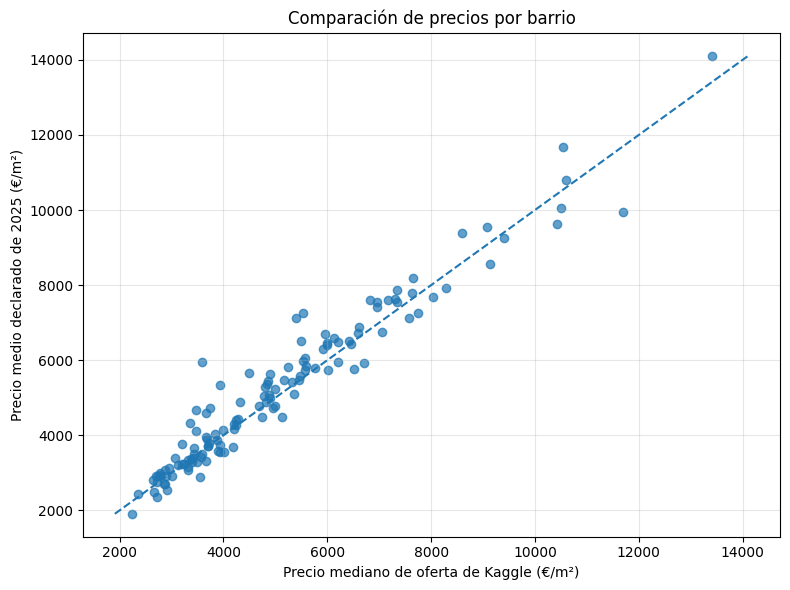

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    comparison["price_m2_median"],
    comparison["registered_price_m2_total_2025"],
    alpha=0.7,
)

minimum = min(
    comparison["price_m2_median"].min(),
    comparison["registered_price_m2_total_2025"].min(),
)
maximum = max(
    comparison["price_m2_median"].max(),
    comparison["registered_price_m2_total_2025"].max(),
)

ax.plot([minimum, maximum], [minimum, maximum], linestyle="--")
ax.set_xlabel("Precio mediano de oferta de Kaggle (€/m²)")
ax.set_ylabel("Precio medio declarado de 2025 (€/m²)")
ax.set_title("Comparación de precios por barrio")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Auditoría de discrepancias

Las diferencias más grandes deben revisarse, especialmente cuando la muestra de Kaggle es pequeña o su fiabilidad es baja. No implican necesariamente un error: ambas fuentes miden conceptos y periodos diferentes.

In [15]:
comparison["absolute_gap_percentage"] = comparison[
    "registered_vs_kaggle_gap_percentage"
].abs()

largest_differences = comparison.sort_values(
    "absolute_gap_percentage",
    ascending=False,
).head(15)

display(
    largest_differences[
        [
            "zone_key",
            "neighborhood_name",
            "district_name",
            "num_listings",
            "price_m2_median",
            "registered_price_m2_total_2025",
            "registered_vs_kaggle_gap_percentage",
            "price_reliability_level",
        ]
    ]
)

,zone_key,neighborhood_name,district_name,num_listings,price_m2_median,registered_price_m2_total_2025,registered_vs_kaggle_gap_percentage,price_reliability_level
71,MAD-096,El Plantío,Moncloa - Aravaca,74,"3,580.19","5,946.59",66.10,low
48,MAD-082,Fuentelarreina,Fuencarral - El Pardo,21,"3,929.54","5,341.25",35.93,low
62,MAD-106,Cuatro Vientos,Latina,15,"3,479.34","4,673.53",34.32,low
5,MAD-024,Legazpi,Arganzuela,39,"5,404.41","7,113.37",31.62,low
46,MAD-088,El Goloso,Fuencarral - El Pardo,12,"5,527.15","7,247.17",31.12,low
112,MAD-124,Almendrales,Usera,40,"3,362.07","4,323.83",28.61,low
75,MAD-142,Horcajo,Moratalaz,2,"3,747.77","4,736.60",26.38,insufficient_sample
40,MAD-154,La Concepción,Ciudad Lineal,75,"4,487.18","5,658.13",26.10,low
120,MAD-194,El Cañaveral,Vicálvaro,75,"3,670.21","4,587.55",24.99,low
14,MAD-111,Comillas,Carabanchel,46,"3,463.44","4,105.51",18.54,low


## 14. Revisión de los barrios previamente problemáticos

Se comprueba expresamente el estado de:

- Atocha y Valdebernardo: sin anuncios válidos en Kaggle, pero con precio oficial.
- Horcajo y Pavones: muestras pequeñas en Kaggle, pero con precio oficial.
- Aeropuerto: sin precio oficial publicable y con una muestra muy reducida en Kaggle.

In [16]:
KEY_NEIGHBORHOODS = [
    "MAD-027",  # Atocha
    "MAD-192",  # Valdebernardo
    "MAD-142",  # Horcajo
    "MAD-141",  # Pavones
    "MAD-212",  # Aeropuerto
]

key_review = enriched.loc[
    enriched["zone_key"].isin(KEY_NEIGHBORHOODS),
    [
        "zone_key",
        "neighborhood_name",
        "district_name",
        "num_listings",
        "price_m2_median",
        "registered_price_m2_total_2025",
        "registered_price_available",
        "kaggle_features_available",
        "price_reliability_level",
        "housing_data_availability_status",
    ],
].sort_values("zone_key")

display(key_review)

,zone_key,neighborhood_name,district_name,num_listings,price_m2_median,registered_price_m2_total_2025,registered_price_available,kaggle_features_available,price_reliability_level,housing_data_availability_status
1,MAD-027,Atocha,Arganzuela,0,NaN,"6,810.36",True,False,no_data,official_price_only
78,MAD-141,Pavones,Moratalaz,4,"3,709.27","3,721.75",True,True,insufficient_sample,official_price_and_kaggle_features
75,MAD-142,Horcajo,Moratalaz,2,"3,747.77","4,736.60",True,True,insufficient_sample,official_price_and_kaggle_features
121,MAD-192,Valdebernardo,Vicálvaro,0,NaN,"4,117.97",True,False,no_data,official_price_only
7,MAD-212,Aeropuerto,Barajas,3,"6,560.98",<NA>,False,True,insufficient_sample,kaggle_features_only


## 15. Construcción de una auditoría compacta

El archivo de auditoría resume para cada barrio:

- Disponibilidad de ambas fuentes.
- Precio de oferta de Kaggle.
- Precio declarado de 2025.
- Diferencia entre fuentes.
- Tamaño y fiabilidad de la muestra de Kaggle.
- Estado final de disponibilidad.

In [17]:
audit_columns = [
    "zone_key",
    "neighborhood_name",
    "district_name",
    "num_listings",
    "has_real_estate_data",
    "price_m2_median",
    "registered_price_m2_total_2025",
    "registered_price_available",
    "kaggle_asking_price_available",
    "kaggle_features_available",
    "kaggle_sample_reliability_score",
    "kaggle_sample_reliability_level",
    "registered_minus_kaggle_eur_m2",
    "registered_vs_kaggle_gap_percentage",
    "housing_data_availability_status",
    "price_m2_for_recommender",
    "price_m2_for_recommender_source",
]

integration_audit = enriched[audit_columns].copy()

display(integration_audit.head())

,zone_key,neighborhood_name,district_name,num_listings,has_real_estate_data,price_m2_median,registered_price_m2_total_2025,registered_price_available,kaggle_asking_price_available,kaggle_features_available,kaggle_sample_reliability_score,kaggle_sample_reliability_level,registered_minus_kaggle_eur_m2,registered_vs_kaggle_gap_percentage,housing_data_availability_status,price_m2_for_recommender,price_m2_for_recommender_source
0,MAD-022,Acacias,Arganzuela,66,True,"6,020.38","5,736.45",True,True,True,47.68,low,-283.93,-4.72,official_price_and_kaggle_features,"5,736.45",registered_transactions_2025
1,MAD-027,Atocha,Arganzuela,0,False,NaN,"6,810.36",True,False,False,NaN,no_data,NaN,NaN,official_price_only,"6,810.36",registered_transactions_2025
2,MAD-023,Chopera,Arganzuela,34,True,"5,165.79","5,473.88",True,True,True,62.98,medium,308.09,5.96,official_price_and_kaggle_features,"5,473.88",registered_transactions_2025
3,MAD-025,Delicias,Arganzuela,60,True,"5,319.93","5,426.01",True,True,True,73.93,medium,106.08,1.99,official_price_and_kaggle_features,"5,426.01",registered_transactions_2025
4,MAD-021,Imperial,Arganzuela,71,True,"5,588.24","5,855.12",True,True,True,68.35,medium,266.88,4.78,official_price_and_kaggle_features,"5,855.12",registered_transactions_2025


## 16. Exportación

Los CSV se guardan con codificación `UTF-8 con BOM` para facilitar su apertura en Excel sin perder tildes.

In [18]:
official_clean.to_csv(
    OFFICIAL_CLEAN_PATH,
    index=False,
    encoding="utf-8-sig",
)

enriched.to_csv(
    ENRICHED_PATH,
    index=False,
    encoding="utf-8-sig",
)

integration_audit.to_csv(
    AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("Archivos generados:")
for path in [OFFICIAL_CLEAN_PATH, ENRICHED_PATH, AUDIT_PATH]:
    print(f"- {path.relative_to(PROJECT_ROOT)}")

Archivos generados:
- data/processed/registered_housing_price_2025.csv
- data/processed/neighborhood_real_estate_enriched.csv
- data/processed/neighborhood_real_estate_integration_audit.csv


## 17. Validaciones finales

Estas comprobaciones detienen el notebook si la integración pierde barrios, crea duplicados o utiliza precios oficiales iguales a cero.

In [19]:
assert len(official_clean) == 131
assert len(enriched) == 131
assert len(integration_audit) == 131

assert official_clean["zone_key"].is_unique
assert enriched["zone_key"].is_unique
assert integration_audit["zone_key"].is_unique

assert set(enriched["zone_key"]) == set(zones["zone_key"])

assert not (
    official_clean[
        [
            "registered_price_m2_total_2025",
            "registered_price_m2_new_2025",
            "registered_price_m2_used_2025",
        ]
    ].fillna(np.nan)
    == 0
).any().any()

assert enriched.loc[
    enriched["zone_key"] == "MAD-027",
    "registered_price_m2_total_2025",
].notna().all(), "Atocha debería tener precio oficial."

assert enriched.loc[
    enriched["zone_key"] == "MAD-192",
    "registered_price_m2_total_2025",
].notna().all(), "Valdebernardo debería tener precio oficial."

assert enriched.loc[
    enriched["zone_key"] == "MAD-212",
    "registered_price_m2_total_2025",
].isna().all(), "Aeropuerto no debería tener un precio oficial inventado."

print("Todas las validaciones finales se han superado.")

Todas las validaciones finales se han superado.


## Conclusiones de la integración

Después de ejecutar este notebook:

- El precio principal por metro cuadrado procede de las compraventas registradas en 2025.
- Kaggle continúa aportando superficie, habitaciones, ascensor, exterior, cobertura y precio histórico de oferta.
- Ambas fuentes permanecen diferenciadas y trazables.
- Atocha y Valdebernardo quedan cubiertos para el análisis de precio, aunque no disponen de características suficientes de Kaggle.
- Aeropuerto permanece sin precio oficial publicable; no se le asigna un valor artificial.
- El archivo `neighborhood_real_estate_enriched.csv` queda preparado para integrarse posteriormente con los tiempos de transporte.